<a href="https://colab.research.google.com/github/aabyyaann/midterm-machine-learning/blob/main/UTS_ML_NaufalAlifAbyan_101032300032.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# UTS Machine Learning - Naufal Alif Abyan (101032300032)
!pip install mlflow optuna lightgbm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import optuna
import lightgbm as lgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

print("Setup Library Berhasil.")

✅ Setup Library Berhasil.


In [41]:
from google.colab import drive
drive.mount('/content/drive')

def find_path(name):
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        if name in files:
            return root + "/"
    return None

PATH = find_path('train_transaction.csv')

if PATH:
    print(f"Memuat data dari: {PATH}")
    # Load Transaction & Identity
    train_trans = pd.read_csv(PATH + 'train_transaction.csv')

    try:
        train_id = pd.read_csv(PATH + 'train_identity.csv')
        # Merge sesuai instruksi soal menggunakan TransactionID
        df = pd.merge(train_trans, train_id, on='TransactionID', how='left')
        print("Berhasil menggabungkan tabel Transaction dan Identity.")
    except:
        df = train_trans
        print("File Identity tidak ditemukan, menggunakan data Transaction saja.")

    # Optimasi memori agar Colab tidak crash
    for col in df.columns:
        if df[col].dtype == 'float64': df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
else:
    print("Folder dataset tidak ditemukan. Pastikan file ada di Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Memuat data dari: /content/drive/MyDrive/Midterm ML/
⚠️ File Identity tidak ditemukan, menggunakan data Transaction saja.


In [42]:
# 1. Pilih Fitur (Mengambil 50 kolom pertama agar running cepat)
X = df.iloc[:, :50].drop(['isFraud', 'TransactionID'], axis=1, errors='ignore')
y = df['isFraud']

# 2. Label Encoding & Handling Missing Values
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Unknown')
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    else:
        X[col] = X[col].fillna(X[col].median())

# 3. Split Data (Stratified karena data imbalance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Optuna Objective dengan Tracking MLFlow
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': True, # Menangani class imbalance sesuai soal
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 31, 150),
        'verbosity': -1
    }

    with mlflow.start_run(nested=True):
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, preds)

        mlflow.log_params(params)
        mlflow.log_metric("auc", auc)
        return auc

print("Memulai Hyperparameter Tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

[I 2026-05-14 11:54:43,996] A new study created in memory with name: no-name-74d13ddd-4f73-45c9-8239-b3350c86a9f7


🚀 Memulai Hyperparameter Tuning...


[I 2026-05-14 11:55:22,839] Trial 0 finished with value: 0.9394210041880663 and parameters: {'learning_rate': 0.04258837546811884, 'num_leaves': 114}. Best is trial 0 with value: 0.9394210041880663.
[I 2026-05-14 11:55:40,984] Trial 1 finished with value: 0.9235125963872759 and parameters: {'learning_rate': 0.013703733818110705, 'num_leaves': 113}. Best is trial 0 with value: 0.9394210041880663.
[I 2026-05-14 11:55:57,824] Trial 2 finished with value: 0.9397135728367596 and parameters: {'learning_rate': 0.0534019921631426, 'num_leaves': 90}. Best is trial 2 with value: 0.9397135728367596.
[I 2026-05-14 11:56:12,290] Trial 3 finished with value: 0.912791445779021 and parameters: {'learning_rate': 0.02683390416846873, 'num_leaves': 44}. Best is trial 2 with value: 0.9397135728367596.
[I 2026-05-14 11:56:31,848] Trial 4 finished with value: 0.9457794583657759 and parameters: {'learning_rate': 0.05493329426334487, 'num_leaves': 128}. Best is trial 4 with value: 0.9457794583657759.



✅ Final AUC Score: 0.9461

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.91      0.48      0.63      4133

    accuracy                           0.98    118108
   macro avg       0.95      0.74      0.81    118108
weighted avg       0.98      0.98      0.98    118108



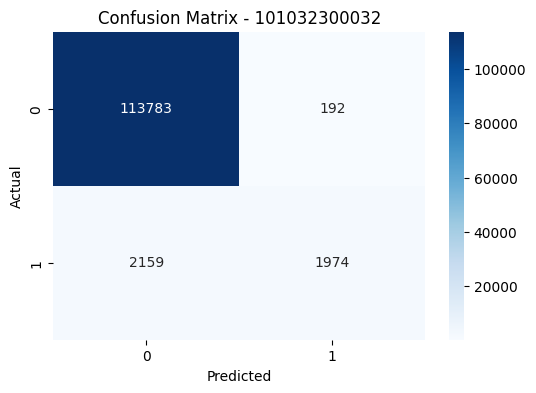

In [43]:
# Latih model terbaik
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X_train, y_train)

# Prediksi
y_pred_prob = best_model.predict_proba(X_val)[:, 1]
y_pred_bin = (y_pred_prob > 0.5).astype(int)

# Visualisasi
print(f"\n Final AUC Score: {roc_auc_score(y_val, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_bin))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred_bin), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {NIM}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()